# Datos y baseline

Este notebook presenta el contrato de datos de InvoiceOps y dos baselines sobre un conjunto sintético determinista. Usa rutas relativas: si el dataset no existe, lo genera desde la API reutilizable del proyecto.

In [1]:
import csv
import json
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

from invoiceops.ml.data import TARGET, generate_synthetic_dataset
from invoiceops.ml.features import MODEL_FEATURES

DATASET_VERSION = "invoice-risk-v1"
DATASET_ROOT = Path("data")
dataset_dir = DATASET_ROOT / DATASET_VERSION
if not dataset_dir.exists():
    generate_synthetic_dataset(
        seed=20260826, rows=12_000, version=DATASET_VERSION, output_root=DATASET_ROOT
    )

with (dataset_dir / "metadata.json").open(encoding="utf-8") as file:
    metadata = json.load(file)


def load_split(name):
    with (dataset_dir / name).open(newline="", encoding="utf-8") as file:
        return list(csv.DictReader(file))


train_rows = load_split("train.csv")
validation_rows = load_split("validation.csv")
test_rows = load_split("test.csv")

split_ranges = {
    split_name: (min(row["submitted_at"] for row in rows), max(row["submitted_at"] for row in rows))
    for split_name, rows in {
        "train": train_rows,
        "validation": validation_rows,
        "test": test_rows,
    }.items()
}

metadata_columns = ["invoice_id", "submitted_at"]
expected_columns = [*metadata_columns, *MODEL_FEATURES, TARGET]
assert len(MODEL_FEATURES) == 8
assert list(train_rows[0]) == expected_columns
assert metadata["target"] == TARGET

## Split temporal

Los registros se ordenan por `submitted_at`: train contiene el pasado y validation un periodo posterior. No se mezclan aleatoriamente, porque eso filtraría información futura. Mostramos el rango de `test.csv` solo para comprobar su posición futura: no se usa para fit, métricas, selección ni decisiones. El futuro no debe contaminar el entrenamiento.

train      2024-01-01T00:40:00+00:00 to 2024-12-15T23:35:00+00:00  no_manual_review= 6539 (77.8%)  manual_review= 1861 (22.2%)
validation 2024-12-16T00:49:00+00:00 to 2025-02-28T23:32:00+00:00  no_manual_review= 1423 (79.1%)  manual_review=  377 (20.9%)
test       2025-03-01T00:30:00+00:00 to 2025-05-14T23:20:00+00:00  range only; not used for fit, metrics, selection, or decisions


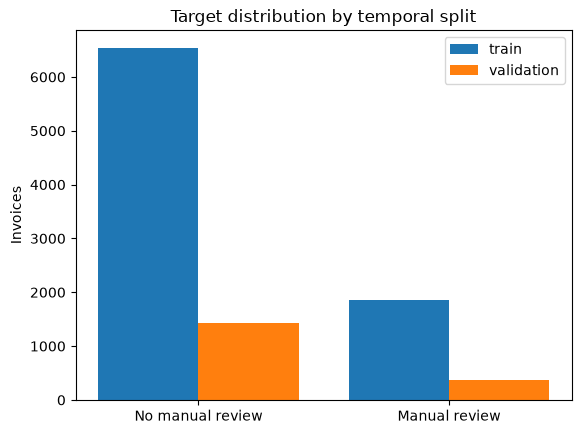

In [2]:
target_distribution = {
    split_name: {
        "no_manual_review": sum(row[TARGET] == "False" for row in rows),
        "manual_review": sum(row[TARGET] == "True" for row in rows),
    }
    for split_name, rows in {"train": train_rows, "validation": validation_rows}.items()
}

for split_name, counts in target_distribution.items():
    total = sum(counts.values())
    start, end = split_ranges[split_name]
    print(
        f"{split_name:10} {start} to {end}  no_manual_review={counts['no_manual_review']:5} ({counts['no_manual_review'] / total:.1%})  manual_review={counts['manual_review']:5} ({counts['manual_review'] / total:.1%})"
    )

test_start, test_end = split_ranges["test"]
print(
    f"{'test':10} {test_start} to {test_end}  range only; not used for fit, metrics, selection, or decisions"
)

labels = ["No manual review", "Manual review"]
train_counts = [
    target_distribution["train"]["no_manual_review"],
    target_distribution["train"]["manual_review"],
]
validation_counts = [
    target_distribution["validation"]["no_manual_review"],
    target_distribution["validation"]["manual_review"],
]
positions = range(len(labels))
plt.bar([position - 0.2 for position in positions], train_counts, width=0.4, label="train")
plt.bar(
    [position + 0.2 for position in positions], validation_counts, width=0.4, label="validation"
)
plt.xticks(list(positions), labels)
plt.ylabel("Invoices")
plt.title("Target distribution by temporal split")
plt.legend()
plt.show()

## Baselines

Primero medimos una predicción constante de 0 (`False`). Después usamos `DummyClassifier(strategy='most_frequent')`, entrenado solamente con train. Ambos se evalúan sobre validation con accuracy, precision, recall y F1.

In [3]:
def feature_matrix(rows):
    return [[row[feature] for feature in MODEL_FEATURES] for row in rows]


y_train = [row[TARGET] == "True" for row in train_rows]
y_validation = [row[TARGET] == "True" for row in validation_rows]
X_train = feature_matrix(train_rows)
X_validation = feature_matrix(validation_rows)

zero_predictions = [False] * len(y_validation)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_predictions = dummy.predict(X_validation)


def metrics_for(predictions):
    return {
        "accuracy": accuracy_score(y_validation, predictions),
        "precision": precision_score(y_validation, predictions, zero_division=0),
        "recall": recall_score(y_validation, predictions, zero_division=0),
        "f1": f1_score(y_validation, predictions, zero_division=0),
    }


baseline_metrics = {
    "constant_zero": metrics_for(zero_predictions),
    "dummy_most_frequent": metrics_for(dummy_predictions),
}
for baseline_name, values in baseline_metrics.items():
    print(baseline_name)
    print("  " + "  ".join(f"{name}={value:.3f}" for name, value in values.items()))

constant_zero
  accuracy=0.791  precision=0.000  recall=0.000  f1=0.000
dummy_most_frequent
  accuracy=0.791  precision=0.000  recall=0.000  f1=0.000


## Matriz de confusión

Las filas son valores reales y las columnas son predicciones. Un falso positivo (FP) envía una factura segura a revisión manual; un falso negativo (FN) deja pasar una factura que requería revisión.

In [4]:
tn, fp, fn, tp = confusion_matrix(y_validation, dummy_predictions, labels=[False, True]).ravel()
print("                 Predicted no review  Predicted manual review")
print(f"Real no review  TN={tn:4}                 FP={fp:4}")
print(f"Real manual     FN={fn:4}                 TP={tp:4}")

                 Predicted no review  Predicted manual review
Real no review  TN=1423                 FP=   0
Real manual     FN= 377                 TP=   0


### Pregunta

Una accuracy alta, por sí sola, ¿implica que el modelo es útil? Considera el coste de un falso negativo: una factura que requería revisión y que el modelo dejó pasar. Si reducir esos FN importa más que el coste de más revisiones manuales, ¿qué métrica y qué umbral deberíamos priorizar en el siguiente modelo?